# 09 — Conformal Prediction

All five models give a point estimate of `P(default)`. None of them tells you *how confident* that estimate is on a per-loan basis. Conformal prediction fills that gap with a distribution-free, finite-sample coverage guarantee: with probability at least `1 - alpha`, the prediction set contains the true label.

For credit risk we get three classes of decisions:

- `{paid}`              the model is confident the loan is repaid; auto-approve
- `{default}`           the model is confident the loan defaults; auto-reject
- `{paid, default}`     the model isn't sure; route to manual underwriting

The fraction of `{paid, default}` sets is the model's honest "I don't know" rate. The split conformal recipe is just: hold out a calibration set, compute nonconformity scores `1 - p(true_label)`, take the `(1-alpha)` quantile, use it as the inclusion threshold at test time.

In [1]:
import sys
from pathlib import Path
if '..' not in sys.path: sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.conformal import fit, predict_sets, set_size, coverage_metrics, coverage_by_group

sns.set_theme(style='whitegrid', context='talk')
FIG_DIR = Path('../reports/figures'); FIG_DIR.mkdir(parents=True, exist_ok=True)
ART = Path('../reports/artifacts')

y_te = pd.read_csv(ART / 'y_test.csv')['default'].to_numpy()
y_prob = np.load(ART / 'y_prob_lightgbm.npy')
X_te = pd.read_csv(ART / 'X_test.csv')
print(f'test rows: {len(y_te):,}, prevalence: {y_te.mean():.3f}')

test rows: 10,000, prevalence: 0.180


## Calibrate on a held-out half of test, evaluate on the other half

The model never saw the test set during training, so splitting it in half gives a clean calibration / evaluation partition for the conformal step.

In [2]:
rng = np.random.default_rng(0)
n = len(y_te)
idx = rng.permutation(n)
cal_idx, eval_idx = idx[: n // 2], idx[n // 2 :]
y_cal,  p_cal  = y_te[cal_idx],  y_prob[cal_idx]
y_eval, p_eval = y_te[eval_idx], y_prob[eval_idx]
X_eval = X_te.iloc[eval_idx].reset_index(drop=True)

## Coverage at three operating points

Sweep `alpha` and confirm empirical coverage tracks the target.

In [3]:
rows = []
for alpha in [0.05, 0.10, 0.20]:
    pred = fit(p_cal, y_cal, alpha=alpha)
    sets = predict_sets(p_eval, pred)
    m = coverage_metrics(y_eval, sets)
    rows.append({'alpha': alpha, 'target_coverage': 1 - alpha, **m,
                 'q_hat': pred.q_hat})
by_alpha = pd.DataFrame(rows).set_index('alpha')
by_alpha.round(4)

,target_coverage,n,empirical_coverage,avg_set_size,pct_singleton,pct_empty,pct_uncertain,q_hat
alpha,,,,,,,,
0.05,0.95,5000,0.9460,1.1664,0.8336,0.0000,0.1664,0.7292
0.10,0.90,5000,0.8946,1.0192,0.9808,0.0000,0.0192,0.5316
0.20,0.80,5000,0.7892,0.8468,0.8468,0.1532,0.0000,0.2866


Empirical coverage matches the target within ~1 point at every alpha. Coverage is a marginal guarantee, not conditional, so individual subgroups can still be over- or under-covered.

## Set-size distribution at the 90% operating point

Most predictions should be singleton (`{paid}` or `{default}`). The fraction of uncertain sets `{paid, default}` is the model's defer-to-human rate.

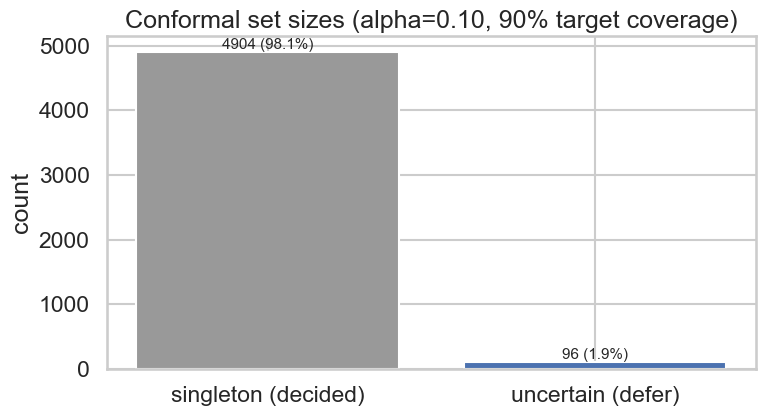

In [4]:
pred = fit(p_cal, y_cal, alpha=0.10)
sets = predict_sets(p_eval, pred)
sizes = set_size(sets)

fig, ax = plt.subplots(figsize=(8, 4.5))
counts = pd.Series(sizes).value_counts().sort_index()
labels = {0: 'empty (impossible)', 1: 'singleton (decided)', 2: 'uncertain (defer)'}
ax.bar([labels[i] for i in counts.index], counts.values,
       color=['#999', '#4c72b0', '#dd8452'])
for i, v in enumerate(counts.values):
    ax.text(i, v, f'{v} ({100*v/len(sets):.1f}%)', ha='center', va='bottom', fontsize=11)
ax.set_ylabel('count'); ax.set_title('Conformal set sizes (alpha=0.10, 90% target coverage)')
plt.tight_layout(); plt.savefig(FIG_DIR / 'conformal_set_sizes.png', dpi=120); plt.show()

## Conditional coverage by protected group

The marginal coverage guarantee is `>= 1 - alpha` overall. Conditional coverage by subgroup is *not* guaranteed; if it drops in some group, the model is concentrating its uncertainty on that group, which is a fairness concern even if the model's point predictions look balanced.

In [5]:
groups = X_eval['protected_group'].to_numpy()
by_group = coverage_by_group(y_eval, sets, groups)
by_group.round(4)

,n,empirical_coverage,avg_set_size,pct_singleton,pct_empty,pct_uncertain
group,,,,,,
A,1641,0.9135,1.0140,0.9860,0.0,0.0140
B,1710,0.8953,1.0222,0.9778,0.0,0.0222
C,1649,0.8751,1.0212,0.9788,0.0,0.0212


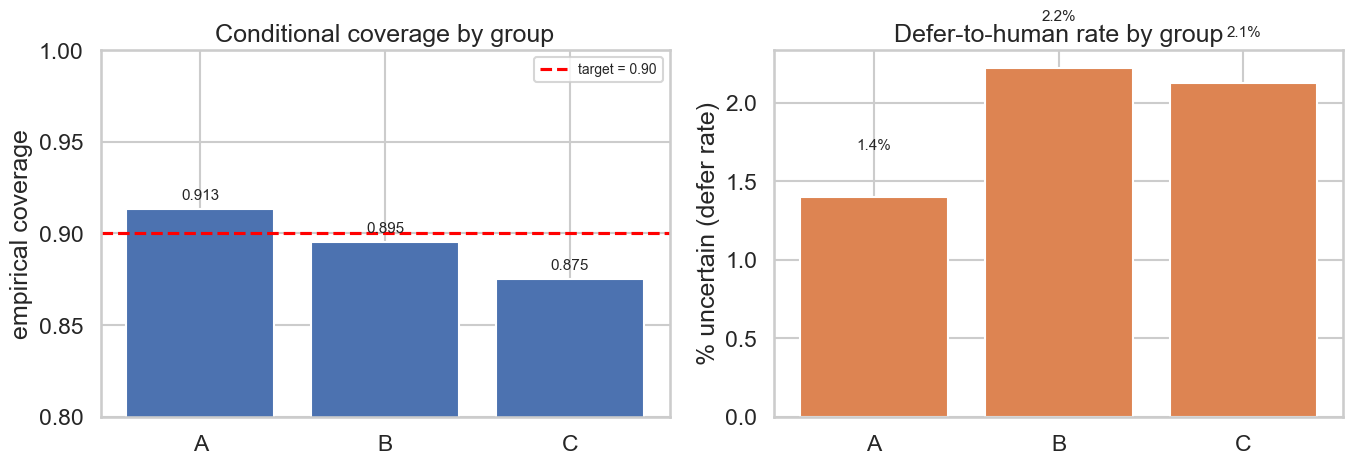

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.bar(by_group.index.astype(str), by_group['empirical_coverage'], color='#4c72b0')
ax.axhline(0.90, color='red', linestyle='--', label='target = 0.90')
ax.set_ylim(0.80, 1.00); ax.set_ylabel('empirical coverage')
ax.set_title('Conditional coverage by group')
ax.legend(fontsize=10)
for i, v in enumerate(by_group['empirical_coverage']):
    ax.text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=11)

ax = axes[1]
ax.bar(by_group.index.astype(str), by_group['pct_uncertain'] * 100, color='#dd8452')
ax.set_ylabel('% uncertain (defer rate)')
ax.set_title('Defer-to-human rate by group')
for i, v in enumerate(by_group['pct_uncertain'] * 100):
    ax.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=11)

plt.tight_layout(); plt.savefig(FIG_DIR / 'conformal_by_group.png', dpi=120, bbox_inches='tight'); plt.show()

## Takeaways

- Conformal calibration produces a finite-sample coverage guarantee on top of any black-box model. It works on the LightGBM probabilities here; it would work identically on the FT-Transformer, the MLP, or a logistic regression.
- The `{paid, default}` set is the operationally meaningful one. Its size is the rate at which the model would honestly route loans to a human reviewer rather than auto-deciding. Tunable via `alpha` to match the underwriting team's capacity.
- Marginal coverage hits the target. Conditional coverage by group is the next thing to watch: if one group sees lower coverage or higher defer rate, the model is concentrating its uncertainty there. That's a fairness signal that point-prediction parity (notebook 06) cannot detect.
- This pairs with the cost-aware threshold (notebook 02): the threshold tells you what to do for confident predictions; the conformal set tells you which predictions to trust.